# 🪔 Doha Generation — Stage 1: Kavita Pre-training
### Encoder-Decoder Transformer with T5-Style Span Corruption
**Hardware:** Dual T4 GPU (DataParallel)  
**Dataset:** 58k Hindi Kavita  
**Objective:** Learn poetic Hindi/Urdu language patterns via span corruption

## 1. Environment Setup & GPU Check

In [1]:
import torch
import os

# Check GPUs
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)} | Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_MULTI_GPU = torch.cuda.device_count() > 1
print(f"\nUsing device: {DEVICE}")
print(f"Multi-GPU (DataParallel): {USE_MULTI_GPU}")

PyTorch version: 2.10.0+cu128
CUDA available: True
Number of GPUs: 2
  GPU 0: Tesla T4 | Memory: 15.6 GB
  GPU 1: Tesla T4 | Memory: 15.6 GB

Using device: cuda
Multi-GPU (DataParallel): True


In [2]:
!pip install -q sentencepiece transformers accelerate

## 2. Imports

In [3]:
import math
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.cuda.amp as amp

import sentencepiece as spm
import json
import time
import warnings
warnings.filterwarnings('ignore')

# Seed everything
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print("All imports done ✅")

All imports done ✅


## 3. Configuration

In [19]:
class Config:
    # ── Paths ──────────────────────────────────────────
    KAVITA_CSV       = '/kaggle/input/datasets/kgan31/complete-kavita-dataset/kavitas_merged.csv'   # <-- update this
    KAVITA_COL       = 'kavita_text'                                   # <-- column name for kavita text
    OUTPUT_DIR       = '/kaggle/working/stage1_output'
    TOKENIZER_PREFIX = '/kaggle/working/stage1_output/hindi_spm'

    # ── Tokenizer ──────────────────────────────────────
    VOCAB_SIZE       = 8000      # small vocab for domain-specific Hindi poetry
    SPM_MODEL_TYPE   = 'bpe'     # bpe works well for Hindi

    # ── Model Architecture ─────────────────────────────
    D_MODEL          = 256       # embedding dim — kept small due to data size
    N_HEADS          = 8
    N_ENC_LAYERS     = 4
    N_DEC_LAYERS     = 4
    D_FF             = 1024      # feedforward dim
    DROPOUT          = 0.1
    MAX_SEQ_LEN      = 256

    # ── Span Corruption ────────────────────────────────
    MASK_PROB        = 0.15      # 15% of tokens get masked
    MEAN_SPAN_LEN    = 3         # average span length to mask

    # ── Training ───────────────────────────────────────
    BATCH_SIZE       = 64        # per GPU — effective = 128 with 2x T4
    EPOCHS           = 50
    LR               = 3e-4
    WARMUP_STEPS     = 500
    WEIGHT_DECAY     = 0.01
    GRAD_CLIP        = 1.0
    VAL_SPLIT        = 0.05      # 5% validation
    SAVE_EVERY       = 5         # save checkpoint every N epochs
    USE_AMP          = True      # mixed precision

    # ── Special Tokens ─────────────────────────────────
    PAD_ID           = 0
    UNK_ID           = 1
    BOS_ID           = 2
    EOS_ID           = 3
    EXTRA_ID_0       = 4         # sentinel token start

cfg = Config()
Path(cfg.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print("Config ready ✅")
print(f"Effective batch size: {cfg.BATCH_SIZE * max(1, torch.cuda.device_count())}")

Config ready ✅
Effective batch size: 128


## 4. Load & Clean Dataset

In [5]:
df = pd.read_csv(cfg.KAVITA_CSV)
print(f"Total rows loaded: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Total rows loaded: 58530
Columns: ['poet_name', 'kavita_name', 'kavita_text', 'kavita_url']


,poet_name,kavita_name,kavita_text,kavita_url
0,अंकित काव्यांश,"ओ मन्दिर के शंख, घण्टियों / अंकित काव्यांश","ओ मन्दिर के शंख, घण्टियों तुम तो बहुत पास रहते...",https://kavitakosh.org/kk/%E0%A4%93_%E0%A4%AE%...
1,अंकित काव्यांश,अभिलाषाओं के दिवास्वप्न / अंकित काव्यांश,अभिलाषाओं केदिवास्वप्न पलकों पर बोझ हुए जातेफि...,https://kavitakosh.org/kk/%E0%A4%85%E0%A4%AD%E...
2,अंकित काव्यांश,मन की मनमानी में / अंकित काव्यांश,तन नौका मेंसवार मन की मनमानी में।स्वप्न हो गये...,https://kavitakosh.org/kk/%E0%A4%AE%E0%A4%A8_%...


In [6]:
def clean_text(text):
    if not isinstance(text, str):
        return None
    text = text.strip()
    # Remove very short kavitas (less than 10 chars)
    if len(text) < 10:
        return None
    # Normalize whitespace
    text = ' '.join(text.split())
    return text

df['clean_kavita'] = df[cfg.KAVITA_COL].apply(clean_text)
df = df.dropna(subset=['clean_kavita']).reset_index(drop=True)

print(f"After cleaning: {len(df)} kavitas")
print(f"\nSample kavita:")
print(df['clean_kavita'].iloc[0][:200])

After cleaning: 58501 kavitas

Sample kavita:
ओ मन्दिर के शंख, घण्टियों तुम तो बहुत पास रहते हो,सच बतलाना क्या पत्थर का ही केवल ईश्वर रहता है?मुझे मिली अधिकांशप्रार्थनाएँ चीखों सँग सीढ़ी पर ही।अनगिन बारथूकती थीं वे हम सबकी इस पीढ़ी पर ही।ओ मन्दिर


In [7]:
# Text length distribution
df['text_len'] = df['clean_kavita'].str.len()
print(df['text_len'].describe())

# Save all kavita texts to a single file for SentencePiece training
corpus_path = f'{cfg.OUTPUT_DIR}/kavita_corpus.txt'
with open(corpus_path, 'w', encoding='utf-8') as f:
    for text in df['clean_kavita']:
        f.write(text + '\n')

print(f"\nCorpus saved to {corpus_path}")

count    58501.000000
mean       571.479154
std        617.869577
min         10.000000
25%        309.000000
50%        447.000000
75%        661.000000
max      40835.000000
Name: text_len, dtype: float64

Corpus saved to /kaggle/working/stage1_output/kavita_corpus.txt


## 5. Train SentencePiece Tokenizer

In [8]:
import sentencepiece as spm

# Number of sentinel tokens (extra_id_0 to extra_id_99)
NUM_SENTINELS = 100

spm.SentencePieceTrainer.train(
    input=corpus_path,
    model_prefix=cfg.TOKENIZER_PREFIX,
    vocab_size=cfg.VOCAB_SIZE,
    model_type=cfg.SPM_MODEL_TYPE,
    pad_id=cfg.PAD_ID,
    unk_id=cfg.UNK_ID,
    bos_id=cfg.BOS_ID,
    eos_id=cfg.EOS_ID,
    pad_piece='<pad>',
    bos_piece='<s>',
    eos_piece='</s>',
    unk_piece='<unk>',
    user_defined_symbols=[f'<extra_id_{i}>' for i in range(NUM_SENTINELS)],
    character_coverage=0.9995,   # high coverage for Devanagari
    num_threads=4,
    input_sentence_size=500000,
    shuffle_input_sentence=True,
)

print("SentencePiece training done ✅")

# Load and test tokenizer
sp = spm.SentencePieceProcessor()
sp.load(f'{cfg.TOKENIZER_PREFIX}.model')

test_text = "बिन पानी साबुन बिना निर्मल न होय"
tokens = sp.encode(test_text, out_type=str)
ids = sp.encode(test_text, out_type=int)
print(f"\nTest text: {test_text}")
print(f"Tokens: {tokens}")
print(f"IDs: {ids}")
print(f"Decoded: {sp.decode(ids)}")
print(f"\nVocab size: {sp.get_piece_size()}")

SentencePiece training done ✅

Test text: बिन पानी साबुन बिना निर्मल न होय
Tokens: ['▁बिन', '▁पानी', '▁साब', 'ुन', '▁बिना', '▁निर्मल', '▁न', '▁होय']
IDs: [1307, 601, 4553, 258, 1182, 5691, 113, 3926]
Decoded: बिन पानी साबुन बिना निर्मल न होय

Vocab size: 8000


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /kaggle/working/stage1_output/kavita_corpus.txt
  input_format: 
  model_prefix: /kaggle/working/stage1_output/hindi_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 500000
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 4
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <extra_id_0>
  user_defined_symbols: <extra_id_1>
  user_defined_symbols: <extra_id_2>
  user_defined_symbols: <extra_id_3>
  user_defined_symbols: <extra_id_4>
  user_defined_symbols: <extra_id_5>
  user_defined_symbols: <extra_id_6>
  user_defined_symbols: <extra_id

## 6. Span Corruption

In [9]:
def apply_span_corruption(token_ids, sp, mask_prob=0.15, mean_span_len=3, extra_id_start=4):
    """
    T5-style span corruption.
    Returns:
        encoder_input : corrupted token ids with sentinel tokens replacing spans
        decoder_target: sentinel tokens followed by the masked span tokens
    """
    n = len(token_ids)
    if n < 4:
        return None, None

    # --- Step 1: decide which positions to mask ---
    mask = np.zeros(n, dtype=bool)
    i = 0
    while i < n:
        if random.random() < mask_prob:
            # sample span length from geometric distribution
            span_len = np.random.geometric(1.0 / mean_span_len)
            span_len = min(span_len, n - i)
            mask[i:i + span_len] = True
            i += span_len
        else:
            i += 1

    # --- Step 2: build encoder input ---
    encoder_input = []
    decoder_target = [cfg.BOS_ID]  # decoder starts with <s>

    sentinel_id = extra_id_start
    in_span = False
    current_span = []

    for j, tok in enumerate(token_ids):
        if mask[j]:
            if not in_span:
                # start new span — add sentinel to encoder
                encoder_input.append(sentinel_id)
                # add sentinel to decoder target
                decoder_target.append(sentinel_id)
                in_span = True
                sentinel_id += 1
                # cap at max sentinels
                if sentinel_id >= extra_id_start + 100:
                    sentinel_id = extra_id_start
            # accumulate span tokens for decoder
            decoder_target.append(tok)
        else:
            in_span = False
            encoder_input.append(tok)

    decoder_target.append(cfg.EOS_ID)  # end sentinel sequence

    return encoder_input, decoder_target


# Quick sanity check
test_ids = sp.encode("बिन पानी साबुन बिना निर्मल न होय", out_type=int)
enc_in, dec_tgt = apply_span_corruption(test_ids, sp)
print("Encoder input tokens:", sp.decode(enc_in))
print("Decoder target tokens:", sp.decode(dec_tgt))
print("\nSpan corruption working ✅")

er.cc(268) LOG(INFO) Added: freq=1288 size=1440 all=233984 active=16633 piece=ख़्त
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1266 size=1460 all=236093 active=18742 piece=आँख
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1245 size=1480 all=238910 active=21559 piece=▁खुल
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1221 size=1500 all=241541 active=24190 piece=▁तुमको
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=1220 min_freq=90
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1198 size=1520 all=243855 active=14294 piece=▁हैएक
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1184 size=1540 all=246510 active=16949 piece=सुबह
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1161 size=1560 all=248930 active=19369 piece=नो
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1146 size=1580 all=252130 active=22569 piece=▁किनारे
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=1132 size=1600 all=254771 active=25210 piece=ृथ्वी
bpe_model_trainer.cc(159) LOG(INFO) Updati

Encoder input tokens: बिन<extra_id_0>ुन बिना निर्मल न होय
Decoder target tokens: <extra_id_0> पानी साब

Span corruption working ✅


## 7. Dataset & DataLoader

In [10]:
class KavitaSpanDataset(Dataset):
    def __init__(self, texts, sp, max_len=256, mask_prob=0.15, mean_span_len=3):
        self.sp = sp
        self.max_len = max_len
        self.mask_prob = mask_prob
        self.mean_span_len = mean_span_len

        # Pre-tokenize all texts
        print("Tokenizing dataset...")
        self.tokenized = []
        for text in tqdm(texts):
            ids = sp.encode(text, out_type=int)
            if len(ids) >= 4:
                self.tokenized.append(ids[:max_len])
        print(f"Valid samples: {len(self.tokenized)}")

    def __len__(self):
        return len(self.tokenized)

    def __getitem__(self, idx):
        token_ids = self.tokenized[idx]
        enc_in, dec_tgt = apply_span_corruption(
            token_ids, self.sp,
            self.mask_prob, self.mean_span_len
        )
        # Retry if corruption returns None
        if enc_in is None:
            return self.__getitem__((idx + 1) % len(self))
        return torch.tensor(enc_in, dtype=torch.long), \
               torch.tensor(dec_tgt, dtype=torch.long)


def collate_fn(batch):
    enc_inputs, dec_targets = zip(*batch)

    # Pad encoder inputs
    enc_max = max(x.size(0) for x in enc_inputs)
    enc_padded = torch.stack([
        F.pad(x, (0, enc_max - x.size(0)), value=cfg.PAD_ID)
        for x in enc_inputs
    ])

    # Pad decoder targets
    dec_max = max(x.size(0) for x in dec_targets)
    dec_padded = torch.stack([
        F.pad(x, (0, dec_max - x.size(0)), value=cfg.PAD_ID)
        for x in dec_targets
    ])

    # Encoder attention mask
    enc_mask = (enc_padded != cfg.PAD_ID)

    return enc_padded, dec_padded, enc_mask


# Train / Val split
all_texts = df['clean_kavita'].tolist()
random.shuffle(all_texts)
val_size  = int(len(all_texts) * cfg.VAL_SPLIT)
train_texts = all_texts[val_size:]
val_texts   = all_texts[:val_size]

print(f"Train: {len(train_texts)} | Val: {len(val_texts)}")

train_dataset = KavitaSpanDataset(train_texts, sp, cfg.MAX_SEQ_LEN, cfg.MASK_PROB, cfg.MEAN_SPAN_LEN)
val_dataset   = KavitaSpanDataset(val_texts,   sp, cfg.MAX_SEQ_LEN, cfg.MASK_PROB, cfg.MEAN_SPAN_LEN)

train_loader = DataLoader(
    train_dataset, batch_size=cfg.BATCH_SIZE,
    shuffle=True, collate_fn=collate_fn,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=cfg.BATCH_SIZE,
    shuffle=False, collate_fn=collate_fn,
    num_workers=2, pin_memory=True
)

print(f"\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train: 55576 | Val: 2925
Tokenizing dataset...


  0%|          | 0/55576 [00:00<?, ?it/s]

Valid samples: 55560
Tokenizing dataset...


  0%|          | 0/2925 [00:00<?, ?it/s]

Valid samples: 2925

Train batches: 869 | Val batches: 46


## 8. Model Architecture

In [11]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class EncoderDecoderTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_enc_layers, n_dec_layers,
                 d_ff, dropout, max_len, pad_id):
        super().__init__()
        self.pad_id = pad_id
        self.d_model = d_model

        # Shared embedding for encoder & decoder
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)

        # Encoder
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True  # Pre-LN for stability
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_enc_layers,
                                              enable_nested_tensor=False)

        # Decoder
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=n_dec_layers)

        # Output projection
        self.output_proj = nn.Linear(d_model, vocab_size, bias=False)

        # Tie output projection weights with embedding (weight tying)
        self.output_proj.weight = self.embedding.weight

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def encode(self, src, src_key_padding_mask):
        x = self.pos_enc(self.embedding(src) * math.sqrt(self.d_model))
        # src_key_padding_mask: True = keep, False = ignore (PyTorch convention is inverted)
        return self.encoder(x, src_key_padding_mask=~src_key_padding_mask)

    def decode(self, tgt, memory, src_key_padding_mask):
        tgt_len = tgt.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_len, device=tgt.device)
        x = self.pos_enc(self.embedding(tgt) * math.sqrt(self.d_model))
        return self.decoder(
            x, memory,
            tgt_mask=tgt_mask,
            memory_key_padding_mask=~src_key_padding_mask
        )

    def forward(self, src, tgt, src_key_padding_mask):
        memory = self.encode(src, src_key_padding_mask)
        dec_out = self.decode(tgt, memory, src_key_padding_mask)
        return self.output_proj(dec_out)


# Instantiate model
model = EncoderDecoderTransformer(
    vocab_size    = sp.get_piece_size(),
    d_model       = cfg.D_MODEL,
    n_heads       = cfg.N_HEADS,
    n_enc_layers  = cfg.N_ENC_LAYERS,
    n_dec_layers  = cfg.N_DEC_LAYERS,
    d_ff          = cfg.D_FF,
    dropout       = cfg.DROPOUT,
    max_len       = cfg.MAX_SEQ_LEN,
    pad_id        = cfg.PAD_ID,
)

# ── Wrap in DataParallel for dual T4 ──
if USE_MULTI_GPU:
    model = nn.DataParallel(model)
    print(f"Model wrapped in DataParallel across {torch.cuda.device_count()} GPUs ✅")

model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,} ({total_params/1e6:.1f}M)")

Model wrapped in DataParallel across 2 GPUs ✅
Trainable parameters: 9,420,800 (9.4M)


## 9. Optimizer, Scheduler & Scaler

In [20]:
optimizer = AdamW(
    model.parameters(),
    lr=cfg.LR,
    weight_decay=cfg.WEIGHT_DECAY,
    betas=(0.9, 0.98),
    eps=1e-9
)

total_steps = len(train_loader) * cfg.EPOCHS
scheduler   = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=1e-6)
scaler      = amp.GradScaler(enabled=cfg.USE_AMP)

criterion = nn.CrossEntropyLoss(ignore_index=cfg.PAD_ID, label_smoothing=0.1)

print(f"Total training steps: {total_steps:,}")
print(f"Optimizer: AdamW | Scheduler: CosineAnnealing | AMP: {cfg.USE_AMP}")

Total training steps: 43,450
Optimizer: AdamW | Scheduler: CosineAnnealing | AMP: True


## 10. Warmup LR Scheduler

In [21]:
class WarmupCosineScheduler:
    """Linear warmup then cosine decay."""
    def __init__(self, optimizer, warmup_steps, total_steps, base_lr, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.total_steps  = total_steps
        self.base_lr      = base_lr
        self.min_lr       = min_lr
        self.step_num     = 0

    def step(self):
        self.step_num += 1
        if self.step_num <= self.warmup_steps:
            lr = self.base_lr * self.step_num / self.warmup_steps
        else:
            progress = (self.step_num - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (1 + math.cos(math.pi * progress))
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr
        return lr

lr_scheduler = WarmupCosineScheduler(
    optimizer,
    warmup_steps=cfg.WARMUP_STEPS,
    total_steps=total_steps,
    base_lr=cfg.LR
)
print("Warmup cosine scheduler ready ✅")

Warmup cosine scheduler ready ✅


## 11. Training & Validation Functions

In [14]:
def train_one_epoch(model, loader, optimizer, scaler, criterion, lr_scheduler):
    model.train()
    total_loss = 0
    total_tokens = 0

    pbar = tqdm(loader, desc='Train', leave=False)
    for enc_input, dec_target, enc_mask in pbar:
        enc_input  = enc_input.to(DEVICE)
        dec_target = dec_target.to(DEVICE)
        enc_mask   = enc_mask.to(DEVICE)

        # Decoder input: all tokens except last
        dec_input = dec_target[:, :-1]
        # Labels: all tokens except first
        labels    = dec_target[:, 1:]

        with amp.autocast(enabled=cfg.USE_AMP):
            logits = model(enc_input, dec_input, enc_mask)
            # logits: (B, T, vocab)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1)
            )

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        lr = lr_scheduler.step()

        non_pad = (labels != cfg.PAD_ID).sum().item()
        total_loss   += loss.item() * non_pad
        total_tokens += non_pad

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{lr:.2e}'})

    return total_loss / total_tokens if total_tokens > 0 else float('inf')


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    total_tokens = 0

    for enc_input, dec_target, enc_mask in tqdm(loader, desc='Val', leave=False):
        enc_input  = enc_input.to(DEVICE)
        dec_target = dec_target.to(DEVICE)
        enc_mask   = enc_mask.to(DEVICE)

        dec_input = dec_target[:, :-1]
        labels    = dec_target[:, 1:]

        with amp.autocast(enabled=cfg.USE_AMP):
            logits = model(enc_input, dec_input, enc_mask)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1)
            )

        non_pad = (labels != cfg.PAD_ID).sum().item()
        total_loss   += loss.item() * non_pad
        total_tokens += non_pad

    avg_loss = total_loss / total_tokens if total_tokens > 0 else float('inf')
    perplexity = math.exp(min(avg_loss, 20))  # cap to avoid overflow
    return avg_loss, perplexity

print("Train/val functions ready ✅")

Train/val functions ready ✅


## 12. Checkpoint Utils

In [22]:
def save_checkpoint(model, optimizer, epoch, val_loss, path):
    # If DataParallel, save the inner module
    model_state = model.module.state_dict() if isinstance(model, nn.DataParallel) \
                  else model.state_dict()
    torch.save({
        'epoch'       : epoch,
        'model_state' : model_state,
        'optim_state' : optimizer.state_dict(),
        'val_loss'    : val_loss,
        'vocab_size'  : sp.get_piece_size(),
        'config'      : {
            'd_model'      : cfg.D_MODEL,
            'n_heads'      : cfg.N_HEADS,
            'n_enc_layers' : cfg.N_ENC_LAYERS,
            'n_dec_layers' : cfg.N_DEC_LAYERS,
            'd_ff'         : cfg.D_FF,
            'max_seq_len'  : cfg.MAX_SEQ_LEN,
        }
    }, path)


def load_checkpoint(model, optimizer, path):
    ckpt = torch.load(path, map_location=DEVICE)
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(ckpt['model_state'])
    else:
        model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optim_state'])
    return ckpt['epoch'], ckpt['val_loss']

print("Checkpoint utils ready ✅")

Checkpoint utils ready ✅


## 13. Main Training Loop

In [23]:
# ── Resume settings ─────────────────────────────────────────
RESUME         = True
RESUME_CKPT    = '/kaggle/working/stage1_output/checkpoint_epoch25.pt'
RESUME_EPOCH   = 25

if RESUME:
    ckpt = torch.load(RESUME_CKPT, map_location=DEVICE)
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(ckpt['model_state'])
    else:
        model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optim_state'])
    best_val_loss = ckpt['val_loss']
    print(f"Resumed from epoch {ckpt['epoch']} | Val Loss: {ckpt['val_loss']:.4f} ✅")
else:
    RESUME_EPOCH  = 0
    best_val_loss = float('inf')

# ── Training loop ────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'val_ppl': []}

print("=" * 60)
print(" Starting Stage 1 Pre-training (Span Corruption on Kavita) ")
print("=" * 60)

for epoch in range(RESUME_EPOCH + 1, cfg.EPOCHS + 1):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, scaler, criterion, lr_scheduler)
    val_loss, val_ppl = validate(model, val_loader, criterion)

    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_ppl'].append(val_ppl)

    print(f"Epoch {epoch:03d}/{cfg.EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val PPL: {val_ppl:.2f} | "
          f"Time: {elapsed:.1f}s")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(model, optimizer, epoch, val_loss,
                        f'{cfg.OUTPUT_DIR}/best_model.pt')
        print(f"  ✅ Best model saved (val_loss={val_loss:.4f})")

    # Periodic checkpoint
    if epoch % cfg.SAVE_EVERY == 0:
        save_checkpoint(model, optimizer, epoch, val_loss,
                        f'{cfg.OUTPUT_DIR}/checkpoint_epoch{epoch}.pt')
        print(f"  💾 Checkpoint saved at epoch {epoch}")

print("\n" + "=" * 60)
print(f" Pre-training Complete! Best Val Loss: {best_val_loss:.4f} ")
print("=" * 60)

Resumed from epoch 25 | Val Loss: 4.9310 ✅
 Starting Stage 1 Pre-training (Span Corruption on Kavita) 


Train:   0%|          | 0/869 [00:00<?, ?it/s]

Val:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 026/50 | Train Loss: 5.0513 | Val Loss: 4.9825 | Val PPL: 145.83 | Time: 99.7s


Train:   0%|          | 0/869 [00:00<?, ?it/s]

...

Val:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 049/50 | Train Loss: 4.6658 | Val Loss: 4.5680 | Val PPL: 96.35 | Time: 99.3s
  ✅ Best model saved (val_loss=4.5680)


Train:   0%|          | 0/869 [00:00<?, ?it/s]

Val:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 050/50 | Train Loss: 4.6564 | Val Loss: 4.5648 | Val PPL: 96.04 | Time: 99.2s
  ✅ Best model saved (val_loss=4.5648)
  💾 Checkpoint saved at epoch 50

 Pre-training Complete! Best Val Loss: 4.5648 


## 14. Plot Training History

ValueError: x and y must have same first dimension, but have shapes (50,) and (25,)

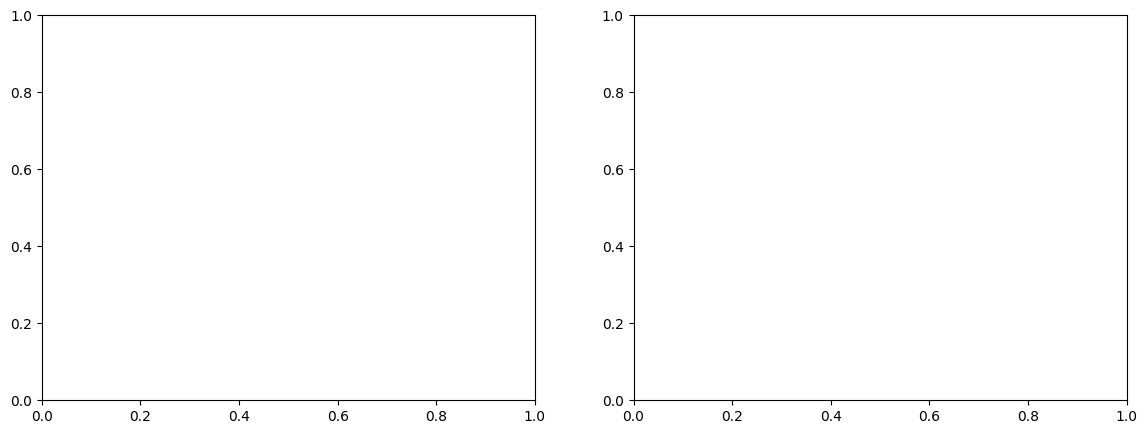

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, cfg.EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='royalblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['val_ppl'], color='seagreen')
axes[1].set_title('Validation Perplexity')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/training_curves.png', dpi=150)
plt.show()
print("Training curves saved ✅")

## 15. Save Tokenizer & Final Artifacts

In [25]:
import shutil

# Copy tokenizer model to output dir
shutil.copy(f'{cfg.TOKENIZER_PREFIX}.model', f'{cfg.OUTPUT_DIR}/tokenizer.model')
shutil.copy(f'{cfg.TOKENIZER_PREFIX}.vocab', f'{cfg.OUTPUT_DIR}/tokenizer.vocab')

# Save training history
with open(f'{cfg.OUTPUT_DIR}/history.json', 'w') as f:
    json.dump(history, f, indent=2)

# Save config
with open(f'{cfg.OUTPUT_DIR}/config.json', 'w') as f:
    config_dict = {k: v for k, v in vars(cfg).items() if not k.startswith('__')}
    json.dump(config_dict, f, indent=2)

print("All artifacts saved ✅")
print(f"\nOutput directory contents:")
for f in sorted(Path(cfg.OUTPUT_DIR).iterdir()):
    print(f"  {f.name} ({f.stat().st_size / 1024:.1f} KB)")

All artifacts saved ✅

Output directory contents:
  best_model.pt (110802.7 KB)
  checkpoint_epoch10.pt (110805.3 KB)
  checkpoint_epoch15.pt (110805.3 KB)
  checkpoint_epoch20.pt (110805.3 KB)
  checkpoint_epoch25.pt (110805.3 KB)
  checkpoint_epoch30.pt (110806.6 KB)
  checkpoint_epoch35.pt (110806.6 KB)
  checkpoint_epoch40.pt (110806.6 KB)
  checkpoint_epoch45.pt (110806.6 KB)
  checkpoint_epoch5.pt (110804.8 KB)
  checkpoint_epoch50.pt (110806.6 KB)
  config.json (0.0 KB)
  hindi_spm.model (405.1 KB)
  hindi_spm.vocab (151.7 KB)
  history.json (1.8 KB)
  kavita_corpus.txt (84738.6 KB)
  tokenizer.model (405.1 KB)
  tokenizer.vocab (151.7 KB)


## 16. Quick Reconstruction Test

In [26]:
@torch.no_grad()
def greedy_decode(model, enc_input_ids, sp, max_gen=50):
    """Simple greedy decoding to test reconstruction quality."""
    # Get the inner model if DataParallel
    m = model.module if isinstance(model, nn.DataParallel) else model
    m.eval()

    enc_tensor = torch.tensor([enc_input_ids], dtype=torch.long).to(DEVICE)
    enc_mask   = (enc_tensor != cfg.PAD_ID).to(DEVICE)
    memory     = m.encode(enc_tensor, enc_mask)

    dec_ids = [cfg.BOS_ID]
    for _ in range(max_gen):
        dec_tensor = torch.tensor([dec_ids], dtype=torch.long).to(DEVICE)
        out = m.decode(dec_tensor, memory, enc_mask)
        logits = m.output_proj(out[:, -1, :])  # last token
        next_id = logits.argmax(-1).item()
        if next_id == cfg.EOS_ID:
            break
        dec_ids.append(next_id)

    return sp.decode(dec_ids[1:])  # skip BOS


# Test on a sample
sample_text = val_texts[0]
sample_ids  = sp.encode(sample_text, out_type=int)[:cfg.MAX_SEQ_LEN]
enc_in, dec_tgt = apply_span_corruption(sample_ids, sp)

print("Original kavita (snippet):")
print(sp.decode(sample_ids[:30]))
print("\nCorrupted encoder input:")
print(sp.decode(enc_in))
print("\nExpected decoder output (masked spans):")
print(sp.decode(dec_tgt))
print("\nModel reconstruction:")
print(greedy_decode(model, enc_in, sp))

Original kavita (snippet):
लम्हा दर लम्हाबीत रही है जिंदगानीसांसो के आवागमन सेमिले इसको रवानीयूं ही साँसों की हलचल मेंन जाने ...कैसे तुम

Corrupted encoder input:
लम्हा दर लम्हाबीत रही है जिंदगानीसांसो के<extra_id_0> हलचल मेंन जाने ...कैसे तुम ज़िंदगी में<extra_id_1> झोंको में बसेमेरी हर<extra_id_2> मेंऔर नस -नस में समाये ..<extra_id_3> वजह यूँ मेरे जीने कीजैसे<extra_id_4> मुसाफिर को...मिले कोई मंजिल का निश<extra_id_5> को ...फ़िर से<extra_id_6>और किसी भटकती रूह कोख्यालो का<extra_id_7> जाए ..<extra_id_8> ....जीने के लिए<extra_id_9>अब ...सोच में<extra_id_10> में बसी साँसों सेतुम्हे<extra_id_11> निकाल<extra_id_12>कैसे जीना<extra_id_13> तुम बिनइस सवाल का उत्तर कहाँ<extra_id_14> ?

Expected decoder output (masked spans):
<extra_id_0> आवागमन सेमिले इसको रवानीयूं ही साँसों की<extra_id_1> आएहवा के<extra_id_2> धड़कन<extra_id_3>बने<extra_id_4> भटके<extra_id_5>ाँवक्त से कटे लम्हे<extra_id_6> मिले पनाह<extra_id_7> तस्वुर दिख<extra_id_8>पर<extra_id_9> जरुरी हैसाँसों का बाहर जाना<extra_id_10> है मेर

---
## ✅ Stage 1 Complete!

**What was trained:**
- Encoder-Decoder Transformer pre-trained on 58k Kavitas
- T5-style span corruption objective (no labels needed)
- Custom BPE tokenizer trained on Hindi poetic corpus
- Dual T4 GPU via `nn.DataParallel`

**Output artifacts for Stage 2:**
- `best_model.pt` — pre-trained weights
- `tokenizer.model` — SentencePiece tokenizer
- `config.json` — model config

**Next → Stage 2:** Fine-tune on 8k Doha dataset with `theme + context → doha` objective

In [ ]:
import shutil

# Zip the entire working directory
shutil.make_archive('/kaggle/working/output', 'zip', '/kaggle/working')

print("Zipped successfully!")